In [1]:
import pandas as pd, numpy as np, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (average_precision_score, f1_score,
                             balanced_accuracy_score, roc_auc_score,
                             matthews_corrcoef)

regions = pd.read_csv("../data/regions_master.csv")
regions = regions[regions['cluster'].notna()].reset_index(drop=True)

emb_data = np.load("../data/features_esm2_region.npz", allow_pickle=True)
emb_X = emb_data['X']
emb_ids = list(emb_data['region_ids'])
emb_idx = {rid: i for i, rid in enumerate(emb_ids)}
regions = regions[regions['region_id'].isin(emb_ids)].reset_index(drop=True)

y = regions['d2o_label'].values.astype(int)
groups = regions['cluster'].astype(int).values

bp = pd.read_csv("../data/features_GO_BP_slim.csv", index_col=0)
mf = pd.read_csv("../data/features_GO_MF_slim.csv", index_col=0)
cc = pd.read_csv("../data/features_GO_CC_slim.csv", index_col=0)

CONDITIONS = {
    1: {'label': 'Seq only',          'bp': False, 'mf': False, 'cc': False},
    2: {'label': 'Seq + BP',          'bp': True,  'mf': False, 'cc': False},
    3: {'label': 'Seq + MF',          'bp': False, 'mf': True,  'cc': False},
    4: {'label': 'Seq + CC',          'bp': False, 'mf': False, 'cc': True },
    5: {'label': 'Seq + BP + MF',     'bp': True,  'mf': True,  'cc': False},
    6: {'label': 'Seq + BP + CC',     'bp': True,  'mf': False, 'cc': True },
    7: {'label': 'Seq + MF + CC',     'bp': False, 'mf': True,  'cc': True },
    8: {'label': 'Seq + BP + MF + CC','bp': True,  'mf': True,  'cc': True },
}

def make_X(condition_id):
    cfg = CONDITIONS[condition_id]
    X_seq = np.stack([emb_X[emb_idx[r]] for r in regions['region_id']])
    parts = [X_seq]
    for mat, present in [(bp, cfg['bp']), (mf, cfg['mf']), (cc, cfg['cc'])]:
        if present:
            parts.append(mat.reindex(regions['acc']).fillna(0).values)
    return np.hstack(parts).astype(np.float32)

cv = GroupKFold(n_splits=5)
splits = list(cv.split(np.zeros(len(regions)), y, groups))
THRESHOLD = float(y.mean())
print(f"n_regions={len(regions)}, positives={y.sum()}, "
      f"clusters={len(np.unique(groups))}, prevalence={THRESHOLD:.3f}")

results = []
for cid in range(1, 9):
    cfg = CONDITIONS[cid]
    X = make_X(cid)
    print(f"\n=== Region-level Condition {cid}: {cfg['label']} (X.shape {X.shape}) ===")
    for fold, (tr, te) in enumerate(splits):
        assert len(set(groups[tr]) & set(groups[te])) == 0
        clf = RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            min_samples_leaf=3, n_jobs=-1, random_state=42)
        clf.fit(X[tr], y[tr])
        proba = clf.predict_proba(X[te])[:, 1]
        pred = (proba >= THRESHOLD).astype(int)
        results.append({
            'condition': cid, 'label': cfg['label'], 'fold': fold,
            'auprc': average_precision_score(y[te], proba),
            'auroc': roc_auc_score(y[te], proba),
            'macro_f1': f1_score(y[te], pred, average='macro'),
            'mcc': matthews_corrcoef(y[te], pred),
        })
        r = results[-1]
        print(f"  Fold {fold}: AUPRC={r['auprc']:.3f}, AUROC={r['auroc']:.3f}, MCC={r['mcc']:.3f}")

results = pd.DataFrame(results)
results.to_csv("../results/region_factorial_rf_per_fold.csv", index=False)
print(results.groupby(['condition','label'])[['auprc','auroc','macro_f1','mcc']].agg(['mean','std']).round(3).to_string())

n_regions=3231, positives=378, clusters=1167, prevalence=0.117

=== Region-level Condition 1: Seq only (X.shape (3231, 1280)) ===
  Fold 0: AUPRC=0.322, AUROC=0.815, MCC=0.260
  Fold 1: AUPRC=0.134, AUROC=0.613, MCC=0.120
  Fold 2: AUPRC=0.345, AUROC=0.786, MCC=0.267
  Fold 3: AUPRC=0.420, AUROC=0.738, MCC=0.262
  Fold 4: AUPRC=0.142, AUROC=0.578, MCC=0.014

=== Region-level Condition 2: Seq + BP (X.shape (3231, 1344)) ===
  Fold 0: AUPRC=0.350, AUROC=0.759, MCC=0.226
  Fold 1: AUPRC=0.140, AUROC=0.639, MCC=0.187
  Fold 2: AUPRC=0.291, AUROC=0.798, MCC=0.266
  Fold 3: AUPRC=0.444, AUROC=0.743, MCC=0.281
  Fold 4: AUPRC=0.142, AUROC=0.582, MCC=0.043

=== Region-level Condition 3: Seq + MF (X.shape (3231, 1316)) ===
  Fold 0: AUPRC=0.405, AUROC=0.813, MCC=0.288
  Fold 1: AUPRC=0.132, AUROC=0.624, MCC=0.119
  Fold 2: AUPRC=0.341, AUROC=0.815, MCC=0.278
  Fold 3: AUPRC=0.445, AUROC=0.752, MCC=0.242
  Fold 4: AUPRC=0.134, AUROC=0.569, MCC=0.051

=== Region-level Condition 4: Seq + CC (X.sha

In [2]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

results_df = pd.DataFrame(results) if isinstance(results, list) else results

wide = results_df.pivot(index='fold', columns='condition', values='auprc')
control = wide[1].values
rows = []
for cid in range(2, 9):
    other = wide[cid].values
    diff = other - control
    w, p = wilcoxon(other, control, alternative='greater', zero_method='wilcox')
    rng = np.random.default_rng(42)
    boots = [diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(2000)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append({'condition': cid, 'label': CONDITIONS[cid]['label'],
                 'mean_diff_vs_seq': diff.mean(), 'ci95_lo': lo, 'ci95_hi': hi,
                 'p_raw': p})

pair = pd.DataFrame(rows)
pair['p_BH'] = multipletests(pair['p_raw'], method='fdr_bh')[1]
pair = pair.round({'mean_diff_vs_seq': 4, 'ci95_lo': 4, 'ci95_hi': 4,
                   'p_raw': 4, 'p_BH': 4})
print("=== Region-level pairwise vs Cond 1 (Seq only), BH-corrected ===")
print(pair.to_string(index=False))

flags = pd.DataFrame([
    {'condition': c, 'BP': int(CONDITIONS[c]['bp']),
                     'MF': int(CONDITIONS[c]['mf']),
                     'CC': int(CONDITIONS[c]['cc'])}
    for c in range(1, 9)])
wlong = wide.stack().rename('auprc').reset_index().merge(flags, on='condition')

def main_effect(col):
    on  = wlong[wlong[col] == 1]['auprc'].mean()
    off = wlong[wlong[col] == 0]['auprc'].mean()
    return on - off

def interaction(a, b):
    g11 = wlong[(wlong[a]==1) & (wlong[b]==1)]['auprc'].mean()
    g10 = wlong[(wlong[a]==1) & (wlong[b]==0)]['auprc'].mean()
    g01 = wlong[(wlong[a]==0) & (wlong[b]==1)]['auprc'].mean()
    g00 = wlong[(wlong[a]==0) & (wlong[b]==0)]['auprc'].mean()
    return (g11 - g10) - (g01 - g00)

print("\n=== Region-level factorial effects on AUPRC ===")
print(f"  Main BP: {main_effect('BP'):+.4f}")
print(f"  Main MF: {main_effect('MF'):+.4f}")
print(f"  Main CC: {main_effect('CC'):+.4f}")
print(f"  Interaction BP×MF: {interaction('BP','MF'):+.4f}")
print(f"  Interaction BP×CC: {interaction('BP','CC'):+.4f}")
print(f"  Interaction MF×CC: {interaction('MF','CC'):+.4f}")

pair.to_csv("../results/region_factorial_rf_stats.csv", index=False)

=== Region-level pairwise vs Cond 1 (Seq only), BH-corrected ===
 condition              label  mean_diff_vs_seq  ci95_lo  ci95_hi  p_raw   p_BH
         2           Seq + BP            0.0006  -0.0278   0.0218 0.3125 0.4375
         3           Seq + MF            0.0190  -0.0050   0.0537 0.4062 0.4740
         4           Seq + CC            0.0246   0.0029   0.0493 0.1562 0.3646
         5      Seq + BP + MF           -0.0115  -0.0410   0.0181 0.8438 0.8438
         6      Seq + BP + CC            0.0404   0.0190   0.0635 0.0312 0.2188
         7      Seq + MF + CC            0.0003  -0.0145   0.0104 0.3125 0.4375
         8 Seq + BP + MF + CC            0.0205   0.0010   0.0513 0.0625 0.2188

=== Region-level factorial effects on AUPRC ===
  Main BP: +0.0015
  Main MF: -0.0093
  Main CC: +0.0194
  Interaction BP×MF: -0.0134
  Interaction BP×CC: +0.0329
  Interaction MF×CC: -0.0255


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

rng = np.random.default_rng(2026)
y_shuffled = rng.permutation(y)
print(f"Shuffled labels: {y_shuffled.sum()} positives (preserved); "
      f"shuffled-vs-original agreement = {(y_shuffled == y).mean():.3f}")

results_neg = []
for cid in range(1, 9):
    cfg = CONDITIONS[cid]
    X = make_X(cid)
    print(f"\n--- shuffled labels: Condition {cid}: {cfg['label']} ---")
    for fold, (tr, te) in enumerate(splits):
        clf = RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            min_samples_leaf=3, n_jobs=-1, random_state=42)
        clf.fit(X[tr], y_shuffled[tr])
        proba = clf.predict_proba(X[te])[:, 1]
        results_neg.append({
            'condition': cid, 'label': cfg['label'], 'fold': fold,
            'auprc': average_precision_score(y_shuffled[te], proba),
            'auroc': roc_auc_score(y_shuffled[te], proba),
        })
        r = results_neg[-1]
        print(f"  Fold {fold}: AUPRC={r['auprc']:.3f}, AUROC={r['auroc']:.3f}")

results_neg = pd.DataFrame(results_neg)
results_neg.to_csv("../results/region_negative_control_per_fold.csv", index=False)

print("\n=== Region-level negative control aggregate ===")
neg_agg = (results_neg.groupby(['condition','label'])['auprc']
                     .agg(['mean','std']).round(3))
print(neg_agg.to_string())
print(f"\nChance AUPRC at region prevalence: {y.mean():.3f}")
print(f"Real-data Cond 1 baseline (W9.4): 0.273")

Shuffled labels: 378 positives (preserved); shuffled-vs-original agreement = 0.796

--- shuffled labels: Condition 1: Seq only ---
  Fold 0: AUPRC=0.137, AUROC=0.512
  Fold 1: AUPRC=0.112, AUROC=0.490
  Fold 2: AUPRC=0.114, AUROC=0.486
  Fold 3: AUPRC=0.150, AUROC=0.504
  Fold 4: AUPRC=0.122, AUROC=0.561

--- shuffled labels: Condition 2: Seq + BP ---
  Fold 0: AUPRC=0.131, AUROC=0.487
  Fold 1: AUPRC=0.110, AUROC=0.490
  Fold 2: AUPRC=0.111, AUROC=0.464
  Fold 3: AUPRC=0.158, AUROC=0.512
  Fold 4: AUPRC=0.127, AUROC=0.581

--- shuffled labels: Condition 3: Seq + MF ---
  Fold 0: AUPRC=0.137, AUROC=0.502
  Fold 1: AUPRC=0.108, AUROC=0.460
  Fold 2: AUPRC=0.114, AUROC=0.481
  Fold 3: AUPRC=0.135, AUROC=0.478
  Fold 4: AUPRC=0.108, AUROC=0.513

--- shuffled labels: Condition 4: Seq + CC ---
  Fold 0: AUPRC=0.161, AUROC=0.516
  Fold 1: AUPRC=0.112, AUROC=0.480
  Fold 2: AUPRC=0.105, AUROC=0.464
  Fold 3: AUPRC=0.149, AUROC=0.512
  Fold 4: AUPRC=0.116, AUROC=0.542

--- shuffled labels: Con

In [4]:
w6 = pd.read_csv("../results/factorial_rf_per_fold.csv").groupby('condition')['auprc'].agg(['mean','std'])
w7 = pd.read_csv("../results/factorial_rf_per_fold_disorder.csv").groupby('condition')['auprc'].agg(['mean','std'])
w9 = results_df.groupby('condition')['auprc'].agg(['mean','std'])

fig, ax = plt.subplots(figsize=(12, 5))
xs = np.arange(1, 9)
ax.errorbar(xs - 0.15, w6['mean'], yerr=w6['std'], fmt='s-', color='#888',
            label=f'W6 whole-protein pool (n=1279, prev=0.147)', capsize=3)
ax.errorbar(xs, w7['mean'], yerr=w7['std'], fmt='o-', color='#3a7',
            label=f'W7 disorder-region pool (n=1279, prev=0.147)', capsize=3)
ax.errorbar(xs + 0.15, w9['mean'], yerr=w9['std'], fmt='^-', color='#a37',
            label=f'W9 region-level (n=3231, prev=0.117)', capsize=3)
ax.axhline(y.mean(), ls=':', color='#a37', alpha=0.5, label='region prevalence')
ax.axhline(0.147, ls=':', color='#888', alpha=0.5, label='protein prevalence')
ax.set_xticks(xs)
ax.set_xticklabels([CONDITIONS[c]['label'] for c in xs], rotation=20, ha='right')
ax.set_ylabel("AUPRC (mean ± std over 5 folds)")
ax.set_title("Factorial AUPRC — three scales of analysis (all flat across conditions)")
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig("../results/figures/region_vs_protein_scale_compare.png", dpi=150)
plt.show()

NameError: name 'plt' is not defined

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

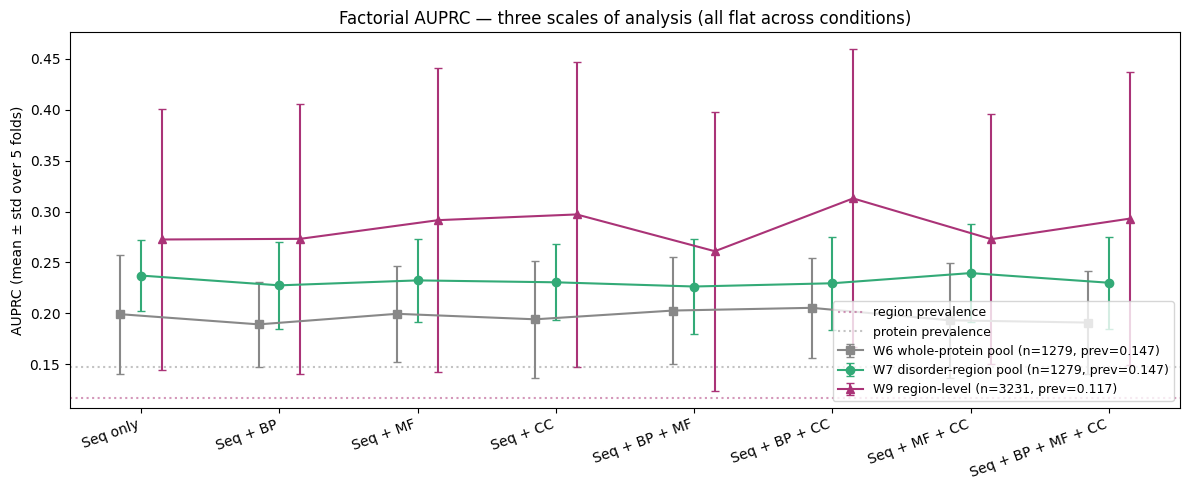

In [6]:
w6 = pd.read_csv("../results/factorial_rf_per_fold.csv").groupby('condition')['auprc'].agg(['mean','std'])
w7 = pd.read_csv("../results/factorial_rf_per_fold_disorder.csv").groupby('condition')['auprc'].agg(['mean','std'])
w9 = results_df.groupby('condition')['auprc'].agg(['mean','std'])

fig, ax = plt.subplots(figsize=(12, 5))
xs = np.arange(1, 9)
ax.errorbar(xs - 0.15, w6['mean'], yerr=w6['std'], fmt='s-', color='#888',
            label=f'W6 whole-protein pool (n=1279, prev=0.147)', capsize=3)
ax.errorbar(xs, w7['mean'], yerr=w7['std'], fmt='o-', color='#3a7',
            label=f'W7 disorder-region pool (n=1279, prev=0.147)', capsize=3)
ax.errorbar(xs + 0.15, w9['mean'], yerr=w9['std'], fmt='^-', color='#a37',
            label=f'W9 region-level (n=3231, prev=0.117)', capsize=3)
ax.axhline(y.mean(), ls=':', color='#a37', alpha=0.5, label='region prevalence')
ax.axhline(0.147, ls=':', color='#888', alpha=0.5, label='protein prevalence')
ax.set_xticks(xs)
ax.set_xticklabels([CONDITIONS[c]['label'] for c in xs], rotation=20, ha='right')
ax.set_ylabel("AUPRC (mean ± std over 5 folds)")
ax.set_title("Factorial AUPRC — three scales of analysis (all flat across conditions)")
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig("../results/figures/region_vs_protein_scale_compare.png", dpi=150)
plt.show()